<a href="https://colab.research.google.com/github/AnnalisaOri/Progetti/blob/main/binomial_model_to_black_scholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The binomial model**

Let us imagine a market with only two periods, \(t=0,1\), representing the present and the future.  
At the future date, only two possible scenarios can occur,
$ ω ∈ {H,T} ≡ Ω $, namely *head* (H) or *tail* (T).

Suppose that, in addition to the bond, there exists only one other asset, called the *stock*.  
Since there are only two assets, we avoid denoting them with the index $ i=0,1 $.  

The bond is risk-free, meaning that its current price is $ 1 $, and its future price is $ e^{r} > 1 $, regardless of the value of $ ω $.  
Note that, under the current assumptions, moving to discounted future quantities amounts to multiplying by  $ e^{-r}$.  

As for the price of the stock — which we denote by $ S $ without subscripts — its evolution can be represented as follows:


$$
S_t =
\begin{cases}
S_0 u, & \text{if } \omega = H, \\
S_0 d, & \text{if } \omega = T.
\end{cases}
$$





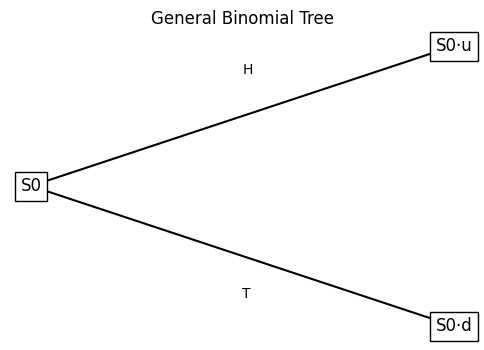

In [9]:

import matplotlib.pyplot as plt

# General parameters
S0 = "S0"  # Initial stock price
u = "u"    # Up factor
d = "d"    # Down factor

# Prices at time t=1
S1_H = f"{S0}·{u}"  # Up state price
S1_T = f"{S0}·{d}"  # Down state price

# Tree structure
tree = {
    0: [S0],
    1: [S1_H, S1_T]
}

# Plot the binomial tree
fig, ax = plt.subplots(figsize=(6, 4))

# Draw edges
ax.plot([0, 1], [0, 1], 'k-')  # Up branch
ax.plot([0, 1], [0, -1], 'k-') # Down branch

# Draw nodes
ax.text(0, 0, S0, ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))

ax.text(1, 1, S1_H, ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))
ax.text(1, -1, S1_T, ha='center', va='center', fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))

# Labels
ax.text(0.5, 0.7, "H", fontsize=10)
ax.text(0.5, -0.8, "T", fontsize=10)

# Remove axes
ax.axis('off')

plt.title("General Binomial Tree")
plt.show()






Becuase there is uncertainty, we assume that $ S_1(H) > S_1(T) $ and we write
$
S_1(H) = u S_0 \quad$ and $ \quad S_1(T) = d S_0, $
so that $ u > d $.

We denote by $ \Delta_0 $ the number of units of the stock purchased at time $t = 0 $, and by $ X_0 $ and $ X_1(\omega) $ the wealth held at time $ t = 0 $ and $ t = 1 $ in scenario $ \omega $, respectively.

Note that, by definition, the number of units of the bond is given by
$
X_0 - \Delta_0 S_0 $,
and therefore doe not need to be represented by a separate symbol.

Under these assumptions, the budget constraint obtained takes the simple form:

\begin{equation}
X_1(\omega) = X_0 e^r + \Delta_0 S_0 \left[ \frac{S_1(\omega)}{S_0} - e^r \right] \\
= X_0 e^r + \Delta_0 S_0 \times
\begin{cases}
u - e^r & \text{se } \omega = H,\\
d - e^r & \text{se } \omega = T.
\end{cases}
\end{equation}


If we assume that no arbitrage opportunities exist,
then the following double inequality must hold:

\begin{equation}
u > e^r > d.
\end{equation}

We note that if the double inequality holds, then in the case $ \Delta_0 > 0 $ we have
$ X_1(H) > 0 > X_1(T) $, while in the case $ \Delta_0 < 0 $ we have $ X_1(T) > 0 > X_1(H) $. Thus, whatever the value of $ \Delta_0 $, there are scenarios in which gains occur and others in which losses occur.

Furthermore, by setting:
$
q = \dfrac{e^r - d}{u - d} $,
the following equality must hold:

\begin{equation}
q \frac{S_1(H)}{S_0} + (1 - q) \frac{S_1(T)}{S_0} = e^r,
\end{equation}

that is,

\begin{equation}
S_0 = e^{-r} \left\{ q S_1(H) + (1 - q) S_1(T) \right\}.
\end{equation}

Since $ q, 1 - q > 0 $, the previous quantities can be expressed as expected values —
that is, we can rewrite the equation as follows:

\begin{equation}
e^r = \mathbb{E}^Q \left[ \frac{S_1}{S_0} \right], \quad
S_0 = e^{-r} \mathbb{E}^Q \left[ S_1 \right].
\end{equation}

We observe that the subscript $Q$ indicates that this expected value is computed using the probability measure $Q$ defined by setting $
Q(H) = q \quad \text{and} \quad Q(T) = 1 - q.$

Notice that the first part of~(1.12) establishes that the gross return
$
\dfrac{S_1}{S_0}$
of the risky asset is equal, in expectation, to the gross risk-free return. Since this equality generally characterizes risk-neutral investors, the measure $Q$ is called the $ risk-neutral probability. $

What we have seen so far can therefore be summarized by stating that the market is free of arbitrage opportunities if and only if there exists a risk-neutral probability measure.


# **The replication principle and complete markets**

The risk-neutral probability was obtained by examining exclusively the bond and the stock. Let us then consider an additional financial asset, described by the value $ V_1(\omega)$ that it pays to the investor at time $ t = 1 $ in the two possible scenarios: $\omega = H $ and $ \omega = T $.

For example, the asset in question could be a $ \textbf{call option} $ written on the stock as the underlying:
\begin{equation}
V_1 = \max(S_1 - K, 0)
\end{equation}

or a $ \textbf{put option} $:
\begin{equation}
V_1 = \max(K - S_1, 0)
\end{equation}

or a $ \textbf{future}$, in which case:
\begin{equation}
V_1 = S_1 - F(0, 1)
\end{equation}

For options, the deterministic quantity $K $ represents the exercise price or strike price at which it is possible to buy the underlying, if it is a call, or to sell it, if it is a put, in case the option is exercised. In a futures contract, $F(0,1) $ represents the forward price of such a transaction.

For these contracts, we want to determine the initial purchase price $V_0 $. To this end, we can consider an investor who initially holds the quantity:
\begin{equation}
V_0 = e^{-r} \left[ V_1(H)q + V_1(T)(1 - q) \right] = e^{-r} \mathbb{E}^Q(V_1)
\end{equation}

and who intends to invest in the stock the quantity:
\begin{equation}
\Delta_{V_0} = \frac{V_1(H) - V_1(T)}{S_1(H) - S_1(T)}
\end{equation}


And in the bond, as usual, the quantity:
\begin{equation}
X_{V_0} - \Delta_{V_0} S_0
= e^{-r} \frac{V_1(T) S_1(H) - V_1(H) S_1(T)}{S_1(H) - S_1(T)}.
\end{equation}

This investment strategy at maturity $ t = 1 $ determines a wealth equal to:
\begin{equation}
\begin{aligned}
X_{V_1} &= X_{V_0} e^{r} + \Delta_{V_0} S_0 \left[ \frac{S_1}{S_0} - e^{r} \right] \\
&= V_1(H) q + V_1(T)(1 - q) + S_0
\frac{V_1(H) - V_1(T)}{S_1(H) - S_1(T)}
\left[ \frac{S_1}{S_0} - e^{r} \right] \\
&= V_1(H) q + V_1(T)(1 - q) +
\frac{V_1(H) - V_1(T)}{u - d}
\left[ \frac{S_1}{S_0} - e^{r} \right] \\
&= \frac{V_1(H)(S_1/S_0 - d) + V_1(T)(u - S_1/S_0)}{u - d} \\
&=
\begin{cases}
V_1(H) & \text{if } \omega = H, \\
V_1(T) & \text{if } \omega = T.
\end{cases}
\end{aligned}
\end{equation}

That is, $ X_{V_1} = V_1 $. In other words, by having the initial wealth $ X_{V_0} $, it is possible to find an investment strategy $ \Delta_{V_0} $ that exactly replicates the considered asset. Therefore, any given asset can be synthetically reproduced by investing in the stock and the bond in appropriate proportions. This property is generally referred to as $ \textbf{market completeness}$ . The property of completeness will also be considered in the general case, where it takes a very particular form. The quantity $ X_{V_0} $ is called the $\textbf{replication price} $ of the asset $ V_1 $.


# **Financial prices**

The result obtained in the previous paragraph, together with the general principle of no arbitrage, provides us with another very important conclusion that answers the question of how the price of the asset with payoff $ V_1 $ should be determined. Indeed, the only possible price for such an asset is its replication price:
\begin{equation}
V_0 = X_{V_0} = e^{-r} \left\{ qV_1(T) + (1 - q)V_1(H) \right\}
= e^{-r} \mathbb{E}^Q[V_1],
\end{equation}
i.e., the discounted expected value calculated using the risk-neutral probability measure $Q$.

The reason is simple: if the inequality $X_{V_0} < V_0$ were true, then the portfolio that replicates $V_1$ — i.e., that pays exactly the same amounts—would cost less than the replicated asset. By buying the replicating portfolio and selling the asset, one would obtain at time $t = 0$ a net inflow
$
X_{V_0} - V_0 < 0
$
and at maturity an obligation to pay
$
V_1 - X_{V_1} = 0.
$
In other words, this would yield a certain profit and a clear arbitrage opportunity.

A similar conclusion arises in the case $V_0 < X_{V_0}$. We thus have here a particular form of the no-arbitrage principle: if there are two assets that produce exactly the same payoff, they must necessarily have the same cost.

Note also that the price of any asset is the discounted expected value calculated using risk-neutral probabilities — the same conclusion that holds for the stock.




This Python code calculates the cost of a replicating portfolio for a derivative using a simple binomial model.
It then compares the cost of the replicating portfolio with the given derivative price.
According to the no-arbitrage principle, these two values must be equal.

In [7]:
import numpy as np

# Parameters of the binomial model
S0 = 100        # Initial stock price
u = 1.2         # Up factor
d = 0.8         # Down factor
r = 0.05        # Risk-free annual interest rate
K = 100         # Strike price of the option (target payoff)

# Stock prices at t=1
S1_H = S0 * u
S1_T = S0 * d

# Payoff of the target security (e.g., a CALL option)
V1_H = max(S1_H - K, 0)   # Payoff in "up" state
V1_T = max(S1_T - K, 0)   # Payoff in "down" state

# Risk-neutral probability
q = (np.exp(r) - d) / (u - d)

# Initial price of the target security
V0 = np.exp(-r) * (q * V1_H + (1 - q) * V1_T)

# Number of shares (Delta) needed to replicate the security
Delta_V0 = (V1_H - V1_T) / (S1_H - S1_T)

# Amount invested in the risk-free bond
Bond_units = V0 - Delta_V0 * S0

# Value of the replicating portfolio at t=1
XV1_H = Delta_V0 * S1_H + Bond_units * np.exp(r)
XV1_T = Delta_V0 * S1_T + Bond_units * np.exp(r)

# Output results
print(f"Initial price of the security V0: {V0:.4f}")
print(f"Delta (number of shares purchased): {Delta_V0:.4f}")
print(f"Bond units purchased: {Bond_units:.4f}")
print(f"Replicated value in up state: {XV1_H:.4f} (Target payoff V1(H)={V1_H})")
print(f"Replicated value in down state: {XV1_T:.4f} (Target payoff V1(T)={V1_T})")

# Check no-arbitrage condition
print("\nNo-arbitrage check:")
if np.isclose(V0, Delta_V0*S0 + Bond_units, atol=1e-6) and \
   np.isclose(XV1_H, V1_H, atol=1e-6) and \
   np.isclose(XV1_T, V1_T, atol=1e-6):
    print("✅ No-arbitrage verified: the price of the security equals the cost of the replicating portfolio.")
else:
    print("❌ Error: no-arbitrage principle violated.")


Initial price of the security V0: 11.9508
Delta (number of shares purchased): 0.5000
Bond units purchased: -38.0492
Replicated value in up state: 20.0000 (Target payoff V1(H)=20.0)
Replicated value in down state: 0.0000 (Target payoff V1(T)=0)

No-arbitrage check:
✅ No-arbitrage verified: the price of the security equals the cost of the replicating portfolio.


# **A generalization**

Let us now consider the most obvious generalization of what was seen above, namely a binomial tree with $N$ step.  
We can think of the underlying probabilistic model as flipping a coin $N$ times, so that an element $\omega$ of the sample space $\Omega$ will now be a sequence

\begin{equation}
\omega = (H_1, T_2, \dots, H_N)
\tag{1.21}
\end{equation}

and thus $\Omega$ is the set of all such sequences. At each flip, the stock price increases, as in the previous case, by a factor $u > 1$ if the outcome is $H$, or decreases by a factor $d < 1$ if the outcome is $T$.  

So, we have the following scenarios (limited here to the case $N=3$):

$
\begin{aligned}
S_0 & \\
S_1(H) &= S_0 u, \\
S_1(T) &= S_0 d, \\
S_2(HH) &= S_0 u^2, \\
S_2(TT) &= S_0 d^2, \\
S_2(HT) &= S_2(TH) = S_0 u d, \\
S_3(HHH) &= S_0 u^3, \\
S_3(HHT), S_3(HTH), S_3(THH) &= S_0 u^2 d, \\
S_3(HTT), S_3(THT), S_3(TTH) &= S_0 u d^2, \\
S_3(TTT) &= S_0 d^3.
\end{aligned}
$



At the final time step $N$, the stock price $S_N$ will take the values:

\begin{equation}
S_N = S_0
\begin{cases}
u^N, & \binom{N}{N} = 1, \\
\vdots & \\
u^k d^{N-k}, & \binom{N}{k}, \\
\vdots & \\
d^N, & \binom{N}{0} = 1.
\end{cases}
\end{equation}



On the right column we report the number of cases in which the same outcome occurs, that is, the number of events $\omega$ in which the outcome $H$ happens $k$ times  
and the outcome $T$ happens $N-k$ times.  

To extend our results from the previous section to the new case of $N$ flips,  
it is useful to fix $0 \le n < N$ and consider the partial sequence  
of the first $n$ flips in the sequence $\omega$:  let us denote this partial sequence by $\omega_n$ and with $\Omega_n$ the set of all sequences of $n$ flips.  

Just as every $\omega$ can be represented graphically as a path along the tree,  
each $\omega_n$ corresponds to the first $n$ branches traversed along that path,  
that is, to the node reached along $\omega$ after $n$ steps.  
Note that the next node, $\omega_{n+1}$, is obtained from $\omega_n$ by adding the outcome of the $(n+1)$-th flip, either $H$ or $T$.  
In other words, $\omega_{n+1} \in \{\omega_nH, \omega_nT\}$.  

Moreover, observe that if $U$ denotes the value of a certain variable along the tree,  
then $U_n(\omega) = U_n(\omega_n)$,  i.e. the value of $U$ after $n$ steps along the path $\omega$ depends only  
on the node $\omega_n$ reached.   

The interest in this notation is that, given $\omega_n$,  
the variable $\omega_{n+1}$ is binary, as it was in the simple model where $N = 1$.  

For example, the evolution of wealth is described at each time $n$ by

\begin{equation}
X_n(\omega_n) = X_{n-1}(\omega_{n-1}) e^r
+ \Delta_{n-1}(\omega_{n-1}) S_{n-1}(\omega_{n-1})
\frac{S_n(\omega_n)}{S_{n-1}(\omega_{n-1})} - e^r,
\end{equation}  

Regarding the pricing formulas obtained earlier, let us again take a variable $V$ that describes the payoff promised by some asset  
at time $t = N$ and, given $V_N = V$, recursively define the following variables for $n = N-1, \dots, 0$:

\begin{equation}
V_n(\omega_n) = e^{-r}*[ q V_{n+1}(\omega_nH) + (1-q) V_{n+1}(\omega_nT)
\end{equation}


\begin{equation}
\Delta V_n(\omega_n) =
\frac{V_{n+1}(\omega_nH) - V_{n+1}(\omega_nT)}
{S_{n+1}(\omega_nH) - S_{n+1}(\omega_nT)}.
\end{equation}


Therefore, $V_n$ is interpreted as the amount of wealth required at time $n$ to replicate at time $n+1$ the quantity $V_{n+1}$, while $\Delta V_n$ represents the amount to invest in the stock to obtain such replication.  

It is therefore clear that if at each time $n$ we have the wealth $V_n$ and invest it  according to the strategy $\Delta V_n$, at the end we will end up with a wealth exactly equal to $V_N = V$,  
that is, we will have replicated the asset $V$.  

Analogously to what was seen for a binomial tree with a single branching,
$V_0$ is the replicating price of the asset $V_N$, and
$(\Delta V_0, \ldots, \Delta V_{N-1})$ is the investment strategy that allows one to replicate $V_N$.

For the same reasons discussed above, $V_0$ is the unique price consistent with the absence of arbitrage opportunities.
Moreover, this quantity can be explicitly computed as
\begin{equation}
V_0 = e^{-Nr}
\sum_{\omega \in \Omega}
V_N(\omega) \, q^{H(\omega)} (1 - q)^{N - H(\omega)}
\end{equation}

Here, $H(\omega)$ denotes the number of times the outcome $H$ appears in a sequence $\omega$ of $N$ trials, and $T(\omega) = N - H(\omega)$ denotes the number of times $T$ appears.
As before, we set
$
q = \dfrac{e^{r} - d}{u - d}
$

Since the outcomes of the trials are independent events, the probability of a sequence $\omega$ under the measure $Q$ is
$
Q(\omega) = q^{H(\omega)} (1 - q)^{N - H(\omega)}.
$

Furthermore,

$
\sum_{\omega \in \Omega}
q^{H(\omega)} (1 - q)^{T(\omega)}
= \sum_{j=0}^{N}
\sum_{\{\omega \in \Omega : H(\omega) = j\}}
q^j (1 - q)^{N - j}
= \sum_{j=0}^{N}
\binom{N}{j}
q^j (1 - q)^{N - j}
= 1,
$

since, as is well known, the binomial coefficient $\binom{N}{j}$ indicates the number of sequences $\omega$ of $N$ trials with $H(\omega) = j$.

Therefore, as before, we can interpret the quantity
$
\sum_{\omega \in \Omega}
V_N(\omega) \, q^{H(\omega)} (1 - q)^{T(\omega)}
$
as the expected value $\mathbb{E}_Q(V_N)$ computed under the probability measure $Q$.


In the special case where $V = h(S_N)$ — that is, when the asset considered is a derivative written on the stock $S$ — then $V$ depends on $\omega$ only through the value of $S_N$, and thus only on the number $H(\omega)$ of times that $H$ occurs in the $N$ trials.
Therefore, equation (1.24) becomes
\begin{align}
V_0
&= e^{-Nr}
\sum_{j=0}^{N}
\sum_{\{\omega \in \Omega : H(\omega) = j\}}
h\!\left(S_0 u^j d^{N-j}\right)
q^j (1 - q)^{N-j} \nonumber\\[4pt]
&= e^{-Nr}
\sum_{j=0}^{N}
\binom{N}{j}
h\!\left(S_0 u^j d^{N-j}\right)
q^j (1 - q)^{N-j}.
\end{align}

If, for example, $V = S_N$, then it becomes
\begin{align*}
e^{-Nr} S_0
\sum_{j=0}^{N}
\binom{N}{j}
u^j d^{N-j}
q^j (1 - q)^{N-j}
&= e^{-Nr} S_0
\sum_{j=0}^{N}
\binom{N}{j}
\left( \frac{u (e^{r} - d)}{u - d} \right)^{j}
\left( \frac{d (u - e^{r})}{u - d} \right)^{N-j} \\[4pt]
&= e^{-Nr} S_0
\left[
\frac{u (e^{r} - d)}{u - d}
+ \frac{d (u - e^{r})}{u - d}
\right]^N \\[4pt]
&= S_0.
\end{align*}


Hence, we obtain the relationship
$
S_0 = e^{-rN} \, \mathbb{E}_Q(S_N),
$
according to which, under the risk-neutral probability,
the current price of the stock is equal to the discounted expected value of its future price.

Risk-neutral probability q = 0.628178

--- Pricing ---
V0 via risk-neutral expectation (formula 1.24): 25.229730
V0 via backward induction: 25.229730
(difference): 7.105427e-15

--- Stock expectation check ---
E_Q[S_N] = 122.140276
Discounted value exp(-r*N) * E_Q[S_N] = 100.000000
Original S0 = 100.000000
Difference S0 - discounted expectation = -1.421085e-14

--- Replicating deltas at early nodes ---
Delta at level 0, j = 0: 0.730867
Delta at level 1, j = 0: 0.426681
Delta at level 1, j = 1: 0.850900

Terminal distribution and payoffs:
   j     S_N  payoff h(S_N)  prob Q(omega)  contribution to E_Q[h(S_N)]
0  0   40.96           0.00       0.019114                     0.000000
1  1   61.44           0.00       0.129166                     0.000000
2  2   92.16           0.00       0.327331                     0.000000
3  3  138.24          38.24       0.368674                    14.098110
4  4  207.36         107.36       0.155715                    16.717552


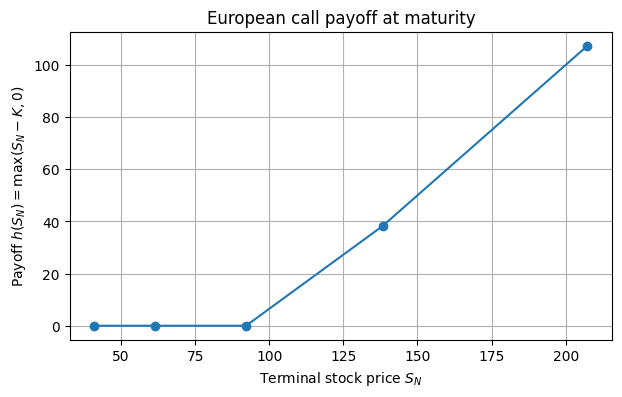

In [1]:
import math
import numpy as np
import pandas as pd
from math import comb, exp
import matplotlib.pyplot as plt

# ==========================================================
# PARAMETERS
# ==========================================================
S0 = 100.0      # initial stock price
u = 1.2         # up factor per period
d = 0.8         # down factor per period
r = 0.05        # continuously compounded interest rate per period
N = 4           # number of periods
K = 100.0       # strike for a European call option

# ==========================================================
# 1. RISK-NEUTRAL PROBABILITY
# ==========================================================
q = (math.exp(r) - d) / (u - d)
if not (0 <= q <= 1):
    raise ValueError(f"q is not in [0,1]. Check parameters. q = {q:.4f}")

print(f"Risk-neutral probability q = {q:.6f}")

# ==========================================================
# 2. TERMINAL STOCK PRICES AND PAYOFF
# ==========================================================
js = np.arange(0, N + 1)                   # number of up moves
S_N = S0 * (u ** js) * (d ** (N - js))     # terminal stock prices
payoff = np.maximum(S_N - K, 0.0)          # European call payoff: max(S_N - K, 0)

# Binomial probabilities under Q
probs = np.array([comb(N, j) * (q ** j) * ((1 - q) ** (N - j)) for j in js])

# ==========================================================
# 3. PRICE VIA EXPECTATION
# ==========================================================
V0_expectation = math.exp(-r * N) * np.sum(payoff * probs)

# ==========================================================
# 4. PRICE VIA BACKWARD INDUCTION
# ==========================================================
option_values = payoff.copy()  # terminal payoffs
for level in range(N - 1, -1, -1):
    next_values = np.empty(level + 1)
    for j in range(level + 1):
        next_values[j] = math.exp(-r) * (q * option_values[j + 1] + (1 - q) * option_values[j])
    option_values = next_values

V0_backward = option_values[0]

# ==========================================================
# 5. VERIFY S0 = e^{-rN} * E_Q[S_N]
# ==========================================================
E_Q_SN = np.sum(S_N * probs)
S0_from_expectation = math.exp(-r * N) * E_Q_SN

# ==========================================================
# 6. REPLICATING DELTAS (first two levels)
# ==========================================================
# Build full option price tree
option_tree = [[None] * (level + 1) for level in range(N + 1)]
for j in range(N + 1):
    option_tree[N][j] = payoff[j]
for level in range(N - 1, -1, -1):
    for j in range(level + 1):
        V_up = option_tree[level + 1][j + 1]
        V_down = option_tree[level + 1][j]
        option_tree[level][j] = math.exp(-r) * (q * V_up + (1 - q) * V_down)

# Compute deltas
deltas = {}
for level in range(0, 2):  # compute only for t = 0 and t = 1
    deltas[level] = []
    for j in range(level + 1):
        V_up = option_tree[level + 1][j + 1]
        V_down = option_tree[level + 1][j]
        stock_here = S0 * (u ** j) * (d ** (level - j))
        delta = (V_up - V_down) / (stock_here * (u - d))
        deltas[level].append(delta)

# ==========================================================
# 7. RESULTS
# ==========================================================
print("\n--- Pricing ---")
print(f"V0 via risk-neutral expectation: {V0_expectation:.6f}")
print(f"V0 via backward induction: {V0_backward:.6f}")
print(f"(difference): {abs(V0_expectation - V0_backward):.6e}")

print("\n--- Stock expectation check ---")
print(f"E_Q[S_N] = {E_Q_SN:.6f}")
print(f"Discounted value exp(-r*N) * E_Q[S_N] = {S0_from_expectation:.6f}")
print(f"Original S0 = {S0:.6f}")
print(f"Difference S0 - discounted expectation = {S0 - S0_from_expectation:.6e}")

print("\n--- Replicating deltas at early nodes ---")
for level in deltas:
    for j, delta in enumerate(deltas[level]):
        print(f"Delta at level {level}, j = {j}: {delta:.6f}")

# ==========================================================
# 8. TABLE AND PLOT
# ==========================================================
df = pd.DataFrame({
    "j": js,
    "S_N": S_N,
    "payoff h(S_N)": payoff,
    "prob Q(omega)": probs,
    "contribution to E_Q[h(S_N)]": payoff * probs
})

print("\nTerminal distribution and payoffs:")
print(df.round(6))

plt.figure(figsize=(7, 4))
plt.plot(S_N, payoff, marker='o')
plt.title("European call payoff at maturity")
plt.xlabel("Terminal stock price $S_N$")
plt.ylabel("Payoff $h(S_N)=\\max(S_N-K,0)$")
plt.grid(True)
plt.show()


# **From the Binomial Model to the Black--Scholes Model**

The binomial model describes the evolution of a stock price in discrete time.
Over each time step of length $\Delta t = T/N$, the stock price can either move up by a factor $u$ or down by a factor $d$.
At maturity $T$, the model yields a discrete set of possible terminal stock prices $S_T$ and corresponding option payoffs.

In contrast, the Black-Scholes model assumes that the stock price evolves continuously according to a geometric Brownian motion:
$
dS_t = r S_t \, dt + \sigma S_t \, dW_t,
$
where $r$ is the continuously compounded risk-free rate, $\sigma$ is the volatility, and $W_t$ is a standard Brownian motion.

Our goal is to choose the binomial model parameters $(u, d, q)$ such that, when the number of time steps $N$ becomes large (so that $\Delta t \to 0$), the binomial model converges to the continuous-time Black-Scholes model.


To ensure this convergence, we set:
$
u = e^{\sigma \sqrt{\Delta t}}, \qquad
d = e^{-\sigma \sqrt{\Delta t}}, \qquad
q = \frac{e^{r \Delta t} - d}{u - d}.
$

These choices guarantee that the expected return and variance of the stock price under the risk-neutral measure match those of the continuous-time process:
$
\mathbb{E}_Q\left[\frac{S_{t+\Delta t}}{S_t}\right] = e^{r \Delta t},
\qquad
\mathrm{Var}_Q\left[\ln\left(\frac{S_{t+\Delta t}}{S_t}\right)\right] = \sigma^2 \Delta t.
$


As $N \to \infty$ (and hence $\Delta t \to 0$), the up and down movements become smaller and more frequent, the discrete distribution of $S_T$ converges to the lognormal distribution implied by the Black-Scholes model and the option price obtained in the binomial model converges to the Black-Scholes price.


Formally,
$
\lim_{N \to \infty} V_0^{(N)} = V_0^{BS},
\quad \text{where} \quad
V_0^{(N)} = e^{-rT} \, \mathbb{E}_Q[h(S_T)].
$



By fixing $u$, $d$, and $q$ according to the Cox-Ross-Rubinstein parametrization, the binomial model becomes a discrete approximation of the continuous Black-Scholes framework.
As the number of steps $N$ increases, the binomial option price converges to the Black-Scholes price, both theoretically and numerically.


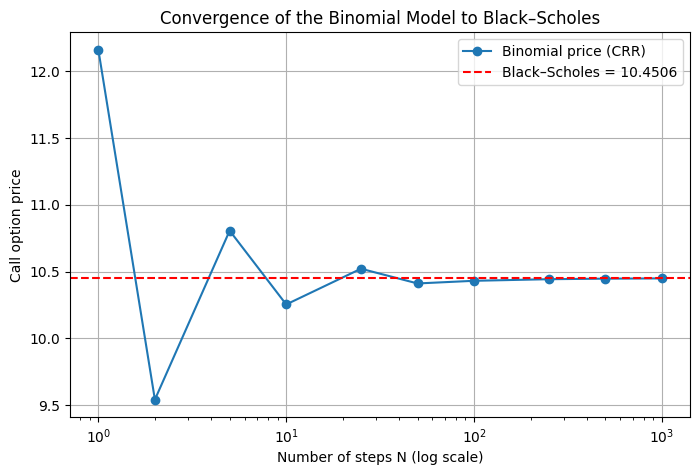


Numerical convergence:
N	Binomial price		Difference from Black–Scholes
   1	12.162285		1.711701e+00
   2	9.540501		9.100822e-01
   5	10.805934		3.553503e-01
  10	10.253409		1.971745e-01
  25	10.520966		7.038205e-02
  50	10.410692		3.989203e-02
 100	10.430612		1.997191e-02
 250	10.442589		7.994860e-03
 500	10.446585		3.998436e-03
1000	10.448584		1.999468e-03


In [3]:
import numpy as np
import math
from scipy.stats import norm
import matplotlib.pyplot as plt

# ===============================
# Basic Parameters
# ===============================
S0 = 100      # initial stock price
K = 100       # strike price
r = 0.05      # continuously compounded risk-free rate
sigma = 0.2   # volatility
T = 1.0       # time to maturity (1 year)

# ===============================
# Black–Scholes Formula (European Call)
# ===============================
def black_scholes_call(S0, K, r, sigma, T):
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S0 * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

BS_price = black_scholes_call(S0, K, r, sigma, T)

# ===============================
# Cox–Ross–Rubinstein Binomial Price (European Call)
# ===============================
def binomial_call_CRR(S0, K, r, sigma, T, N):
    dt = T / N
    u = math.exp(sigma * math.sqrt(dt))       # up factor
    d = math.exp(-sigma * math.sqrt(dt))      # down factor
    q = (math.exp(r * dt) - d) / (u - d)      # risk–neutral probability

    # Terminal stock prices after N steps
    js = np.arange(N + 1)
    S_T = S0 * (u ** js) * (d ** (N - js))
    payoff = np.maximum(S_T - K, 0)           # call payoff: max(S_T - K, 0)

    # Binomial probabilities under Q
    probs = np.array([math.comb(N, j) * (q ** j) * ((1 - q) ** (N - j)) for j in js])

    # Present value of expected payoff
    return math.exp(-r * T) * np.sum(payoff * probs)

# ===============================
# Numerical Comparison for Different N
# ===============================
Ns = [1, 2, 5, 10, 25, 50, 100, 250, 500, 1000]
binomial_prices = [binomial_call_CRR(S0, K, r, sigma, T, N) for N in Ns]

# ===============================
# Visualization of Convergence
# ===============================
plt.figure(figsize=(8, 5))
plt.plot(Ns, binomial_prices, marker='o', label="Binomial price (CRR)")
plt.axhline(BS_price, color='red', linestyle='--', label=f"Black–Scholes = {BS_price:.4f}")
plt.xscale('log')
plt.xlabel("Number of steps N (log scale)")
plt.ylabel("Call option price")
plt.title("Convergence of the Binomial Model to Black–Scholes")
plt.grid(True)
plt.legend()
plt.show()

# ===============================
# Tabular Output
# ===============================
print("\nNumerical convergence:")
print("N\tBinomial price\t\tDifference from Black–Scholes")
for N, v in zip(Ns, binomial_prices):
    print(f"{N:4d}\t{v:.6f}\t\t{abs(v - BS_price):.6e}")
